**Imports and data loading**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score



# Load dataset
data_file = 'Debernardi et al 2020 data.csv'
data = pd.read_csv(data_file)


**Data Preprocessing**

Data Types and Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590 entries, 0 to 589
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   sample_id                590 non-null    object 
 1   patient_cohort           590 non-null    object 
 2   sample_origin            590 non-null    object 
 3   age                      590 non-null    int64  
 4   sex                      590 non-null    object 
 5   diagnosis                590 non-null    int64  
 6   stage                    199 non-null    object 
 7   benign_sample_diagnosis  208 non-null    object 
 8   plasma_CA19_9            350 non-null    float64
 9   creatinine               590 non-null    float64
 10  LYVE1                    590 non-null    float64
 11  REG1B                    590 non-null    float64
 12  TFF1                     590 non-null    float64
 13  REG1A                    306 non-null    float64

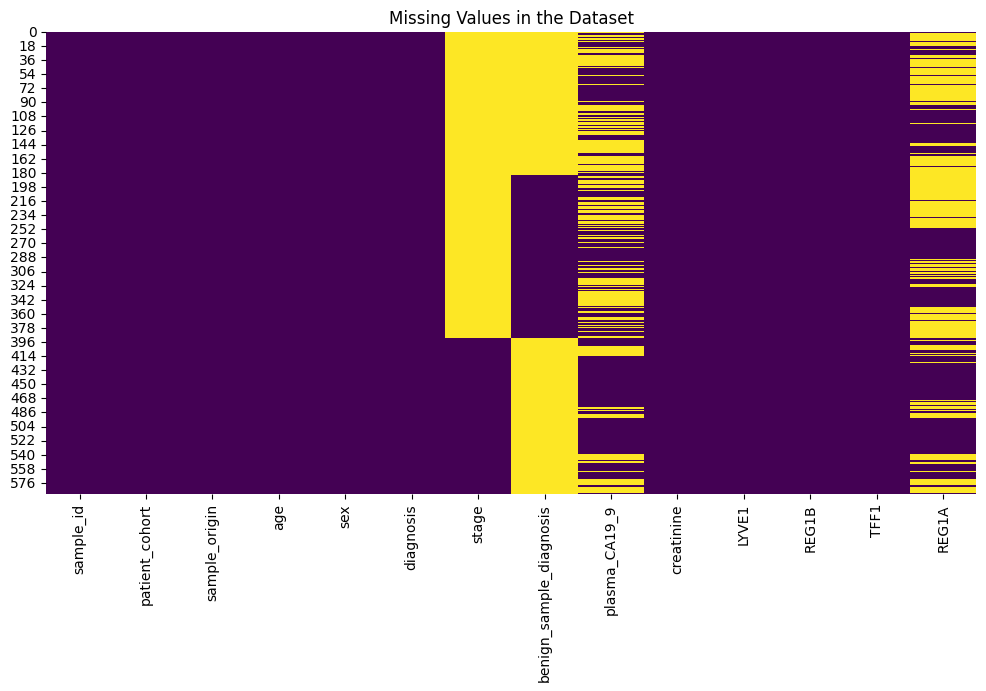

In [2]:
# Display basic information about the dataset
print("Data Types and Non-Null Counts:")
print(data.info())

print("\nSummary Statistics:")
print(data.describe(include='all'))

print("\nMissing Values Per Column:")
print(data.isnull().sum())

# Visualize the missing values in the dataset
plt.figure(figsize=(12, 6))
sns.heatmap(data.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values in the Dataset')
plt.show()

In [3]:
# Drop  columns with significant missing values.
columns_to_drop = ['stage', 'sample_id', 'sample_origin', 'benign_sample_diagnosis', 'REG1A', 'plasma_CA19_9']
columns_to_drop = [col for col in columns_to_drop if col in data.columns]
data.drop(columns=columns_to_drop, inplace=True)
data.head()

# Outlier detection using IQR on numeric columns only
numeric_cols = data.select_dtypes(include=[np.number])
Q1 = numeric_cols.quantile(0.25)
Q3 = numeric_cols.quantile(0.75)
IQR = Q3 - Q1
outliers = ((numeric_cols < (Q1 - 1.5 * IQR)) | (numeric_cols > (Q3 + 1.5 * IQR))).any(axis=1)

# Print outliers
print("Outliers identified:")
print(data[outliers])


Outliers identified:
    patient_cohort  age sex  diagnosis  creatinine      LYVE1       REG1B  \
144        Cohort1   48   F          1     3.44955   4.512589  138.798730   
151        Cohort1   57   M          1     2.38641   5.953427  543.553920   
210        Cohort2   73   M          2     1.13100   4.860454  704.236000   
230        Cohort2   62   M          2     2.75964   5.883500  201.015000   
252        Cohort1   38   F          2     2.29593   0.009184    5.366192   
..             ...  ...  ..        ...         ...        ...         ...   
580        Cohort1   46   M          3     0.75777  10.578610  206.526460   
582        Cohort2   58   F          3     2.39772   0.289500    6.824000   
583        Cohort2   84   M          3     0.66729   5.764349  950.080000   
584        Cohort2   66   M          3     0.93873   7.085637  815.136000   
589        Cohort1   74   M          3     1.50423   8.200958  411.938275   

            TFF1  
144  1876.588322  
151    97.258522

In [4]:
# Encode categorical variables
label_encoders = {}
categorical_columns = ['sex', 'patient_cohort']
for column in categorical_columns:
    le = LabelEncoder()
    data[column] = le.fit_transform(data[column])
    label_encoders[column] = le

# Convert diagnosis to binary
data['diagnosis_binary'] = data['diagnosis'].apply(lambda x: 1 if x == 1 else 0)
data.drop('diagnosis', axis=1, inplace=True)



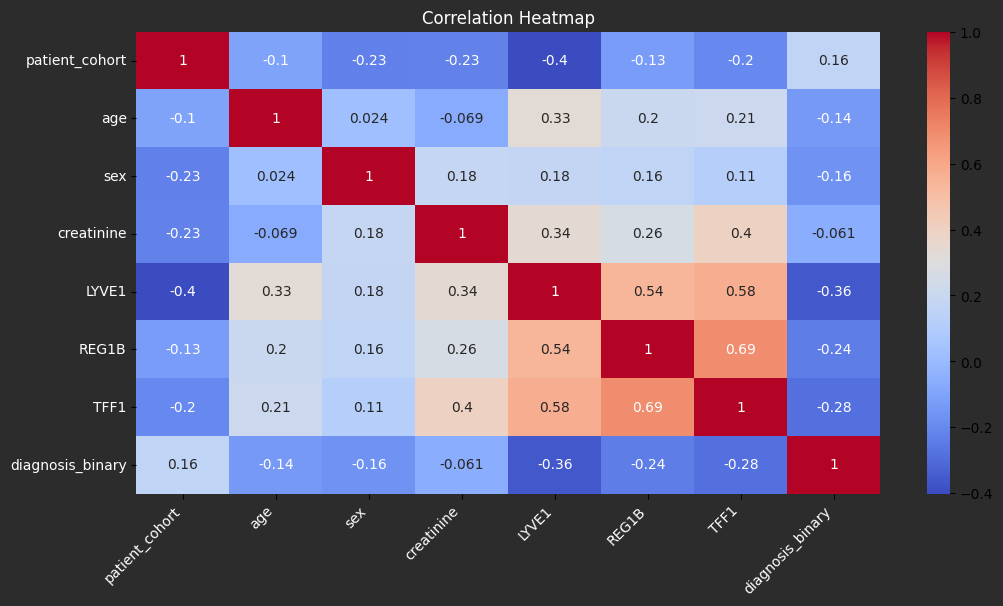

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the background color to grey
plt.figure(figsize=(12, 6), facecolor='#2c2c2c')
ax = sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap', color='white')

# Set the color of the axes labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right', color='white')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, color='white')

# Set the color of the title
ax.title.set_color('white')

# Set the color of the heatmap face
ax.set_facecolor('#2c2c2c')

plt.show()


In [6]:
# Check for class imbalance
print("Class Distribution in Target Variable:")
print(data['diagnosis_binary'].value_counts())

Class Distribution in Target Variable:
diagnosis_binary
0    407
1    183
Name: count, dtype: int64


Feature engineering

In [7]:
# Create interaction terms for features with moderate correlations
data['LYVE1_REG1B'] = data['LYVE1'] * data['REG1B']
data['LYVE1_TFF1'] = data['LYVE1'] * data['TFF1']
data['REG1B_TFF1'] = data['REG1B'] * data['TFF1']

# Update feature matrix
X = data.drop(columns=['diagnosis_binary'])
y = data['diagnosis_binary']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply SMOTE to the training set
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Check the distribution of the target variable after SMOTE
resampled_class_distribution = pd.Series(y_train_resampled).value_counts()
print("Resampled class distribution:\n", resampled_class_distribution)

# Normalize the resampled training data
numerical_features = ['age', 'creatinine', 'LYVE1', 'REG1B', 'TFF1', 'LYVE1_REG1B', 'LYVE1_TFF1', 'REG1B_TFF1']
scaler = StandardScaler()
X_train_resampled[numerical_features] = scaler.fit_transform(X_train_resampled[numerical_features])

# Normalize the test data
X_test[numerical_features] = scaler.transform(X_test[numerical_features])

Resampled class distribution:
 diagnosis_binary
0    326
1    326
Name: count, dtype: int64


**Baseline Models**

Linear SVM CV Accuracy: 0.7439 +/- 0.0483
KNN CV Accuracy: 0.7714 +/- 0.0208
SVM CV Accuracy: 0.7823 +/- 0.0431
Test Accuracy (Linear SVM):  0.6779661016949152
Test Classification Report (Linear SVM):
               precision    recall  f1-score   support

           0       0.85      0.64      0.73        81
           1       0.49      0.76      0.60        37

    accuracy                           0.68       118
   macro avg       0.67      0.70      0.66       118
weighted avg       0.74      0.68      0.69       118

Test Accuracy (KNN):  0.6694915254237288
Test Classification Report (KNN):
               precision    recall  f1-score   support

           0       0.88      0.60      0.72        81
           1       0.48      0.81      0.61        37

    accuracy                           0.67       118
   macro avg       0.68      0.71      0.66       118
weighted avg       0.75      0.67      0.68       118

Test Accuracy (SVM):  0.6864406779661016
Test Classification Report 

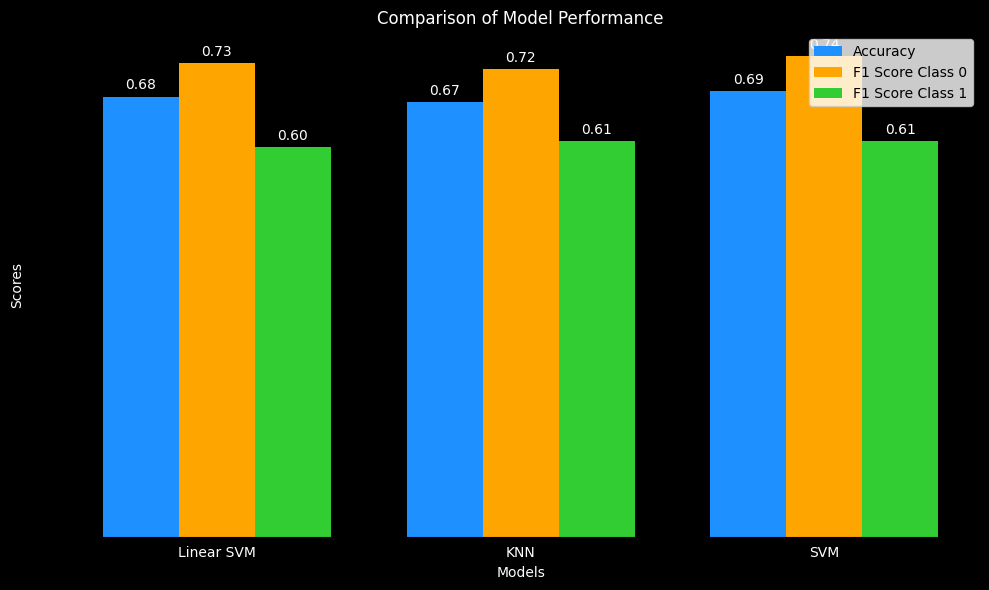

In [8]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import numpy as np

# Initialize models
linear_svm = SVC(kernel='linear', random_state=42)
knn = KNeighborsClassifier()
svm = SVC()

# Define cross-validation method
cv_method = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation and collect results
linear_svm_scores = cross_val_score(linear_svm, X_train_resampled, y_train_resampled, cv=cv_method, scoring='accuracy')
knn_scores = cross_val_score(knn, X_train_resampled, y_train_resampled, cv=cv_method, scoring='accuracy')
svm_scores = cross_val_score(svm, X_train_resampled, y_train_resampled, cv=cv_method, scoring='accuracy')

print(f"Linear SVM CV Accuracy: {linear_svm_scores.mean():.4f} +/- {linear_svm_scores.std():.4f}")
print(f"KNN CV Accuracy: {knn_scores.mean():.4f} +/- {knn_scores.std():.4f}")
print(f"SVM CV Accuracy: {svm_scores.mean():.4f} +/- {svm_scores.std():.4f}")

# Fit the models on the entire resampled training set and evaluate on the test set
linear_svm.fit(X_train_resampled, y_train_resampled)
knn.fit(X_train_resampled, y_train_resampled)
svm.fit(X_train_resampled, y_train_resampled)

# Assuming X_test is already defined and scaled
y_test_pred_linear_svm = linear_svm.predict(X_test)
y_test_pred_knn = knn.predict(X_test)
y_test_pred_svm = svm.predict(X_test)

test_accuracy_linear_svm = accuracy_score(y_test, y_test_pred_linear_svm)
test_accuracy_knn = accuracy_score(y_test, y_test_pred_knn)
test_accuracy_svm = accuracy_score(y_test, y_test_pred_svm)

classification_report_test_linear_svm = classification_report(y_test, y_test_pred_linear_svm)
classification_report_test_knn = classification_report(y_test, y_test_pred_knn)
classification_report_test_svm = classification_report(y_test, y_test_pred_svm)

print("Test Accuracy (Linear SVM): ", test_accuracy_linear_svm)
print("Test Classification Report (Linear SVM):\n", classification_report_test_linear_svm)

print("Test Accuracy (KNN): ", test_accuracy_knn)
print("Test Classification Report (KNN):\n", classification_report_test_knn)

print("Test Accuracy (SVM): ", test_accuracy_svm)
print("Test Classification Report (SVM):\n", classification_report_test_svm)

# Extract F1 scores for each class from the classification report
def extract_f1_scores(classification_report_str):
    lines = classification_report_str.split('\n')
    f1_scores = []
    for line in lines[2:-5]:
        f1_score = line.split()[-2]
        f1_scores.append(float(f1_score))
    return f1_scores

f1_scores_class_0_linear_svm, f1_scores_class_1_linear_svm = extract_f1_scores(classification_report_test_linear_svm)
f1_scores_class_0_knn, f1_scores_class_1_knn = extract_f1_scores(classification_report_test_knn)
f1_scores_class_0_svm, f1_scores_class_1_svm = extract_f1_scores(classification_report_test_svm)

# Data from the models
models = ['Linear SVM', 'KNN', 'SVM']
accuracies = [test_accuracy_linear_svm, test_accuracy_knn, test_accuracy_svm]

# F1-scores for each class
f1_scores_class_0 = [f1_scores_class_0_linear_svm, f1_scores_class_0_knn, f1_scores_class_0_svm]
f1_scores_class_1 = [f1_scores_class_1_linear_svm, f1_scores_class_1_knn, f1_scores_class_1_svm]

x = np.arange(len(models))  # the label locations
width = 0.25  # the width of the bars

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('black')
ax.set_facecolor('black')

# Plotting the bars
rects1 = ax.bar(x - width, accuracies, width, label='Accuracy', color='dodgerblue')
rects2 = ax.bar(x, f1_scores_class_0, width, label='F1 Score Class 0', color='orange')
rects3 = ax.bar(x + width, f1_scores_class_1, width, label='F1 Score Class 1', color='limegreen')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Models', color='white')
ax.set_ylabel('Scores', color='white')
ax.set_title('Comparison of Model Performance', color='white')
ax.set_xticks(x)
ax.set_xticklabels(models, color='white')
ax.legend()

# Attach a text label above each bar in rects, displaying its height.
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', color='white')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

fig.tight_layout()
plt.show()


**Tuned Models**

Fitting 5 folds for each of 4 candidates, totalling 20 fits


[CV] END ..............................................C=0.1; total time=   0.0s
[CV] END ..............................................C=0.1; total time=   0.0s
[CV] END ..............................................C=0.1; total time=   0.0s
[CV] END ..............................................C=0.1; total time=   0.0s
[CV] END ..............................................C=0.1; total time=   0.0s
[CV] END ................................................C=1; total time=   0.0s
[CV] END ................................................C=1; total time=   0.0s
[CV] END ................................................C=1; total time=   0.0s
[CV] END ..............................................C=100; total time=   0.1s
[CV] END ...............................................C=10; total time=   0.0s
[CV] END ................................................C=1; total time=   0.0s
[CV] END ..............................................C=100; total time=   0.1s
[CV] END ...................

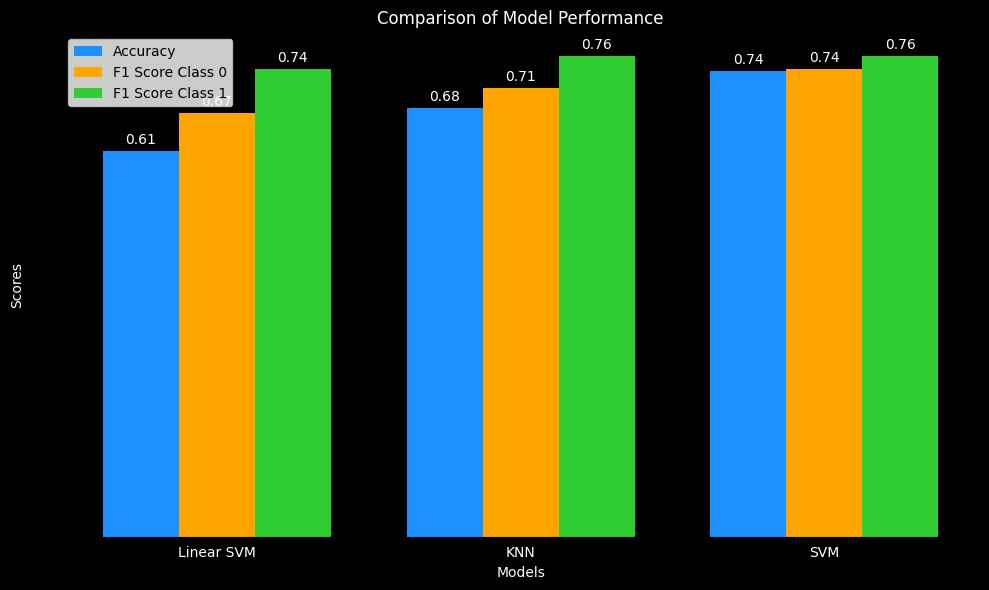

In [9]:
import numpy as np
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# Feature engineering function
def add_interaction_terms(df):
    df['LYVE1_REG1B'] = df['LYVE1'] * df['REG1B']
    df['LYVE1_TFF1'] = df['LYVE1'] * df['TFF1']
    df['REG1B_TFF1'] = df['REG1B'] * df['TFF1']
    return df

# Apply feature engineering to both train and test sets
X_train = add_interaction_terms(X_train)
X_test = add_interaction_terms(X_test)

# Cross-validation method
cv_method = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Parameter grids for tuning
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['linear', 'rbf']
}

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

# Tuning and evaluating Linear SVM
linear_svm = SVC(kernel='linear', random_state=42)
grid_search_linear_svm = GridSearchCV(estimator=linear_svm, param_grid={'C': [0.1, 1, 10, 100]}, cv=cv_method, n_jobs=-1, verbose=2)
grid_search_linear_svm.fit(X_train_resampled, y_train_resampled)
best_params_linear_svm = grid_search_linear_svm.best_params_
best_linear_svm = grid_search_linear_svm.best_estimator_
y_test_pred_linear_svm = best_linear_svm.predict(X_test)
test_accuracy_linear_svm = accuracy_score(y_test, y_test_pred_linear_svm)
classification_report_test_linear_svm = classification_report(y_test, y_test_pred_linear_svm)

# Tuning and evaluating KNN
knn = KNeighborsClassifier()
grid_search_knn = GridSearchCV(estimator=knn, param_grid=param_grid_knn, cv=cv_method, n_jobs=-1, verbose=2)
grid_search_knn.fit(X_train_resampled, y_train_resampled)
best_params_knn = grid_search_knn.best_params_
best_knn = grid_search_knn.best_estimator_
y_test_pred_knn = best_knn.predict(X_test)
test_accuracy_knn = accuracy_score(y_test, y_test_pred_knn)
classification_report_test_knn = classification_report(y_test, y_test_pred_knn)

# Tuning and evaluating SVM
svm = SVC()
grid_search_svm = GridSearchCV(estimator=svm, param_grid=param_grid_svm, cv=cv_method, n_jobs=-1, verbose=2)
grid_search_svm.fit(X_train_resampled, y_train_resampled)
best_params_svm = grid_search_svm.best_params_
best_svm = grid_search_svm.best_estimator_
y_test_pred_svm = best_svm.predict(X_test)
test_accuracy_svm = accuracy_score(y_test, y_test_pred_svm)
classification_report_test_svm = classification_report(y_test, y_test_pred_svm)

# Print results
print("Best Parameters (Linear SVM): ", best_params_linear_svm)
print("Test Accuracy (Linear SVM): ", test_accuracy_linear_svm)
print("Test Classification Report (Linear SVM):\n", classification_report_test_linear_svm)

print("Best Parameters (KNN): ", best_params_knn)
print("Test Accuracy (KNN): ", test_accuracy_knn)
print("Test Classification Report (KNN):\n", classification_report_test_knn)

print("Best Parameters (SVM): ", best_params_svm)
print("Test Accuracy (SVM): ", test_accuracy_svm)
print("Test Classification Report (SVM):\n", classification_report_test_svm)

# Visualizing the comparison
models = ['Linear SVM', 'KNN', 'SVM']
accuracies = [test_accuracy_linear_svm, test_accuracy_knn, test_accuracy_svm]

# F1-scores for each class
f1_scores_class_0 = [
    float(classification_report_test_linear_svm.split()[-9]),
    float(classification_report_test_knn.split()[-9]),
    float(classification_report_test_svm.split()[-9])
]
f1_scores_class_1 = [
    float(classification_report_test_linear_svm.split()[-4]),
    float(classification_report_test_knn.split()[-4]),
    float(classification_report_test_svm.split()[-4])
]

x = np.arange(len(models))  # the label locations
width = 0.25  # the width of the bars

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('black')
ax.set_facecolor('black')

# Plotting the bars
rects1 = ax.bar(x - width, accuracies, width, label='Accuracy', color='dodgerblue')
rects2 = ax.bar(x, f1_scores_class_0, width, label='F1 Score Class 0', color='orange')
rects3 = ax.bar(x + width, f1_scores_class_1, width, label='F1 Score Class 1', color='limegreen')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Models', color='white')
ax.set_ylabel('Scores', color='white')
ax.set_title('Comparison of Model Performance', color='white')
ax.set_xticks(x)
ax.set_xticklabels(models, color='white')
ax.legend()

# Attach a text label above each bar in rects, displaying its height.
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', color='white')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

fig.tight_layout()
plt.show()
